# Practicumopdracht 2 — Regressie Analyse
## Open University Learning Analytics Dataset (OULAD)



**Cursus:** Data Science  
**Dataset:** Open University Learning Analytics Dataset (OULAD)  
**Bron:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/349/open+university+learning+analytics+dataset)  
**Doel:** Het voorspellen van de gemiddelde toetsscore van studenten (`score`) op basis van demografische gegevens en online leergedrag.


## Cel 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import f_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Alle packages succesvol geladen.')

Alle packages succesvol geladen.



## Stap 1  Dataset Introductie

### Wat wordt er voorspeld?
We voorspellen de **gemiddelde toetsscore** (`avg_score`) van een student  
een continue variabele op een schaal van **0 tot 100**.

### Waarom is dit een regressieprobleem?
De doelvariabele `avg_score` is **continu en numeriek**: we willen een exacte 
waarde voorspellen, geen categorie. Regressie is de juiste aanpak wanneer de 
output een oneindig aantal mogelijke waarden kan aannemen binnen een bereik.

### Dataset beschrijving
De **Open University Learning Analytics Dataset (OULAD)** bevat gegevens van 
meer dan 32.000 studenten aan de Open Universiteit (VK). We combineren twee bestanden:
- `studentInfo.csv` — demografische en studiegegevens per student
- `studentAssessment.csv` — toetsresultaten per student

### Data Dictionary

| Variabele | Type | Beschrijving |
|-----------|------|-------------|
| `code_module` | Categorisch | Modulecode (AAA t/m GGG) |
| `code_presentation` | Categorisch | Semester (2013B, 2014J, etc.) |
| `gender` | Categorisch | Geslacht student (M/F) |
| `region` | Categorisch | Woonregio in het VK |
| `highest_education` | Categorisch | Hoogst behaalde vooropleiding |
| `imd_band` | Categorisch | Sociaaleconomische status (0-10% = meest benadeeld) |
| `age_band` | Categorisch | Leeftijdscategorie (0-35, 35-55, 55<=) |
| `num_of_prev_attempts` | Numeriek | Aantal eerdere pogingen voor de module |
| `studied_credits` | Numeriek | Aantal studiepunten dat de student volgt |
| `disability` | Categorisch | Heeft de student een beperking (Y/N) |
| `num_assessments` | Numeriek | Aantal ingeleverde opdrachten |
| `std_score` | Numeriek | Variatie in scores (consistentie van de student) |
| `min_score` | Numeriek | Laagste behaalde score |
| `max_score` | Numeriek | Hoogste behaalde score |
| `avg_date_submitted` | Numeriek | Gemiddeld aantal dagen na start module ingeleverd |
| `total_banked` | Numeriek | Aantal gebankeerde opdrachten |
| `avg_score` | Numeriek (**target**) | Gemiddelde toetsscore (0–100) — te voorspellen |

## Stap 2  Dataset Laden en Samenvoegen

De OULAD dataset bestaat uit meerdere bestanden. We laden de drie relevante bestanden en voegen ze samen tot één DataFrame:

1. **`studentInfo.csv`** — demografische en studiegegevens per student
2. **`studentAssessment.csv`** — toetsscores per student
3. **`studentVle.csv`** — klikgedrag per student in de online leeromgeving

We berekenen per student:
- De **gemiddelde toetsscore** (target variabele)
- Het **totaal aantal klikken** in de VLE (gedragsfeature)


In [2]:
# Bestanden laden
student_info = pd.read_csv('data/studentInfo.csv')
student_assessment = pd.read_csv('data/studentAssessment.csv')

print(f'studentInfo:       {student_info.shape}')
print(f'studentAssessment: {student_assessment.shape}')

studentInfo:       (32593, 12)
studentAssessment: (173912, 5)


### Data Samenvoegen

We berekenen per student meerdere features uit `studentAssessment.csv`:
- **avg_score** — gemiddelde toetsscore (doelvariabele)
- **num_assessments** — aantal ingeleverde opdrachten
- **std_score** — variatie in scores tussen opdrachten
- **min_score** — laagste behaalde score
- **max_score** — hoogste behaalde score
- **avg_date_submitted** — gemiddeld hoe laat opdrachten worden ingeleverd
- **total_banked** — aantal gebankeerde opdrachten

### Motivatie: waarom min_score en max_score naast avg_score?

Op het eerste gezicht lijkt het circulair om `min_score` en `max_score` 
te gebruiken als features om `avg_score` te voorspellen , ze zijn immers 
allemaal afgeleid uit dezelfde toetsscores.

De motivatie voor deze keuze is een formatief scenario: we simuleren 
een situatie waarbij een docent halverwege het semester al de resultaten 
van de eerste toetsen beschikbaar heeft, en op basis daarvan de 
verwachte eindgemiddelde score wil schatten.

In dit scenario zijn min_score en max_score vroege tussentijdse 
toetsresultaten , ze zijn bekend vóórdat het eindgemiddelde wordt 
berekend. Dit is geen data leakage maar een realistische 
voorspellingstaak.

 **Bewuste keuze:**  In dit geval 
 rechtvaardigt het formatieve scenario het gebruik van deze features.

In [3]:
# Score naar numeriek
student_assessment['score'] = pd.to_numeric(
    student_assessment['score'], errors='coerce'
)

# Features per student berekenen
student_features = (
    student_assessment
    .dropna(subset=['score'])
    .groupby('id_student')
    .agg(
        avg_score=('score', 'mean'),
        num_assessments=('id_assessment', 'count'),
        std_score=('score', 'std'),
        min_score=('score', 'min'),
        max_score=('score', 'max'),
        avg_date_submitted=('date_submitted', 'mean'),
        total_banked=('is_banked', 'sum')
    )
    .reset_index()
)

# Studenten met slechts 1 opdracht hebben geen std — opvullen met 0
student_features['std_score'] = student_features['std_score'].fillna(0)

print(f'Student features: {student_features.shape}')
student_features.head()

Student features: (23351, 8)


,id_student,avg_score,num_assessments,std_score,min_score,max_score,avg_date_submitted,total_banked
0,6516,61.800000,5,10.329569,48.0,77.0,111.600000,0
1,8462,87.000000,7,4.472136,83.0,93.0,23.000000,4
2,11391,82.000000,5,3.082207,78.0,85.0,112.400000,0
3,23629,82.500000,4,20.273135,63.0,100.0,55.750000,0
4,23698,74.444444,9,13.258121,56.0,94.0,133.444444,0


In [4]:
# Samenvoegen met studentInfo
df = (
    student_info
    .merge(student_features, on='id_student', how='inner')
    .drop(columns=['id_student', 'final_result'], errors='ignore')
)

print(f'Finale dataset: {df.shape[0]} rijen x {df.shape[1]} kolommen')
print(f'\nKolommen: {list(df.columns)}')
df.head()

Finale dataset: 26727 rijen x 17 kolommen

Kolommen: ['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'avg_score', 'num_assessments', 'std_score', 'min_score', 'max_score', 'avg_date_submitted', 'total_banked']


,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,avg_score,num_assessments,std_score,min_score,max_score,avg_date_submitted,total_banked
0,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,82.0,5,3.082207,78.0,85.0,112.4,0
1,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,66.4,5,4.335897,60.0,70.0,114.2,0
2,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,76.0,5,6.892024,71.0,88.0,112.2,0
3,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,54.4,5,20.513410,30.0,75.0,125.6,0
4,AAA,2013J,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,68.0,5,10.977249,50.0,79.0,116.2,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26727 entries, 0 to 26726
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           26727 non-null  object 
 1   code_presentation     26727 non-null  object 
 2   gender                26727 non-null  object 
 3   region                26727 non-null  object 
 4   highest_education     26727 non-null  object 
 5   imd_band              26727 non-null  object 
 6   age_band              26727 non-null  object 
 7   num_of_prev_attempts  26727 non-null  int64  
 8   studied_credits       26727 non-null  int64  
 9   disability            26727 non-null  object 
 10  avg_score             26727 non-null  float64
 11  num_assessments       26727 non-null  int64  
 12  std_score             26727 non-null  float64
 13  min_score             26727 non-null  float64
 14  max_score             26727 non-null  float64
 15  avg_date_submitted 

In [6]:
df.describe().round(2)

,num_of_prev_attempts,studied_credits,avg_score,num_assessments,std_score,min_score,max_score,avg_date_submitted,total_banked
count,26727.00,26727.00,26727.00,26727.00,26727.00,26727.00,26727.00,26727.00,26727.00
mean,0.16,77.77,72.83,7.75,12.67,53.66,87.65,98.78,0.13
std,0.47,39.03,15.56,4.54,8.22,22.56,15.86,41.43,0.80
min,0.00,30.00,0.00,1.00,0.00,0.00,0.00,-4.00,0.00
25%,0.00,60.00,64.80,4.00,7.07,40.00,81.00,71.97,0.00
50%,0.00,60.00,75.71,7.00,11.88,58.00,93.00,108.91,0.00
75%,0.00,90.00,84.06,11.00,17.30,70.00,100.00,124.00,0.00
max,6.00,630.00,100.00,28.00,70.00,100.00,100.00,315.56,12.00


In [7]:
# Ontbrekende waarden
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Ontbrekend': missing, 'Percentage (%)': missing_pct})

,Ontbrekend,Percentage (%)
code_module,0,0.0
code_presentation,0,0.0
gender,0,0.0
region,0,0.0
highest_education,0,0.0
imd_band,0,0.0
age_band,0,0.0
num_of_prev_attempts,0,0.0
studied_credits,0,0.0
disability,0,0.0



## Stap 2 — Exploratieve Data Analyse (EDA)

In deze stap verkennen we de data visueel en statistisch. We bekijken:
- De verdeling van de doelvariabele `avg_score`
- De verdeling van numerieke en categorische features
- Relaties tussen features en de target via scatter plots
- Een correlatiematrix om verbanden te identificeren

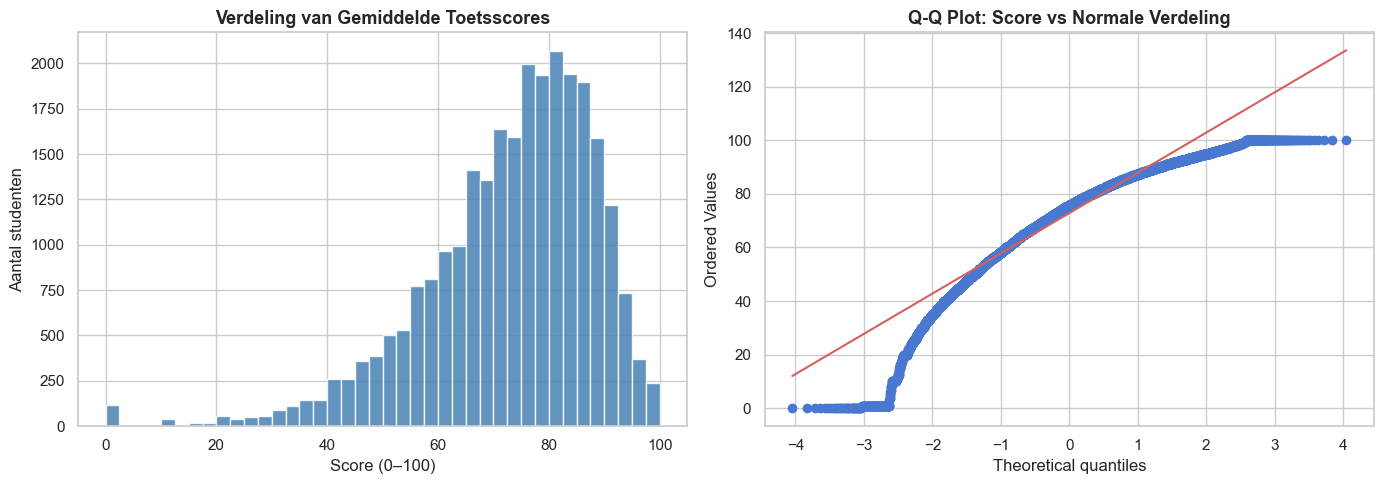

Gemiddelde:  72.83
Mediaan:     75.71
Std:         15.56
Sckewness:  -1.183
Kurtosis:    2.251


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['avg_score'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Verdeling van Gemiddelde Toetsscores', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score (0–100)')
axes[0].set_ylabel('Aantal studenten')

stats.probplot(df['avg_score'].dropna(), dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Score vs Normale Verdeling', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Gemiddelde:  {df['avg_score'].mean():.2f}")
print(f"Mediaan:     {df['avg_score'].median():.2f}")
print(f"Std:         {df['avg_score'].std():.2f}")
print(f"Sckewness:  {df['avg_score'].skew():.3f}")
print(f"Kurtosis:    {df['avg_score'].kurtosis():.3f}")

### Interpretatie  Verdeling van de Doelvariabele

- **Scheefheid = -1.183**: de verdeling is **linksscheef**  de meeste studenten 
  scoren hoog, maar er is een lange staart naar links met studenten die zeer laag scoren.
- **Gemiddelde (72.83) < Mediaan (75.71)**: bevestigt de linkse scheefheid  
  lage uitbijters trekken het gemiddelde naar beneden.
- **Q-Q plot**: de sterke S-vorm toont duidelijke afwijkingen van normaliteit, 
  vooral aan de linkerstaart (scores rond 0). Dit zijn studenten die opdrachten 
  niet hebben ingeleverd.
- **Kurtosis = 2.251**: de verdeling is iets piekiger dan een normale verdeling.

Deze niet-normale verdeling is belangrijk om in gedachten te houden bij de 
residuenanalyse later in het notebook.

### Verdeling numerieke features

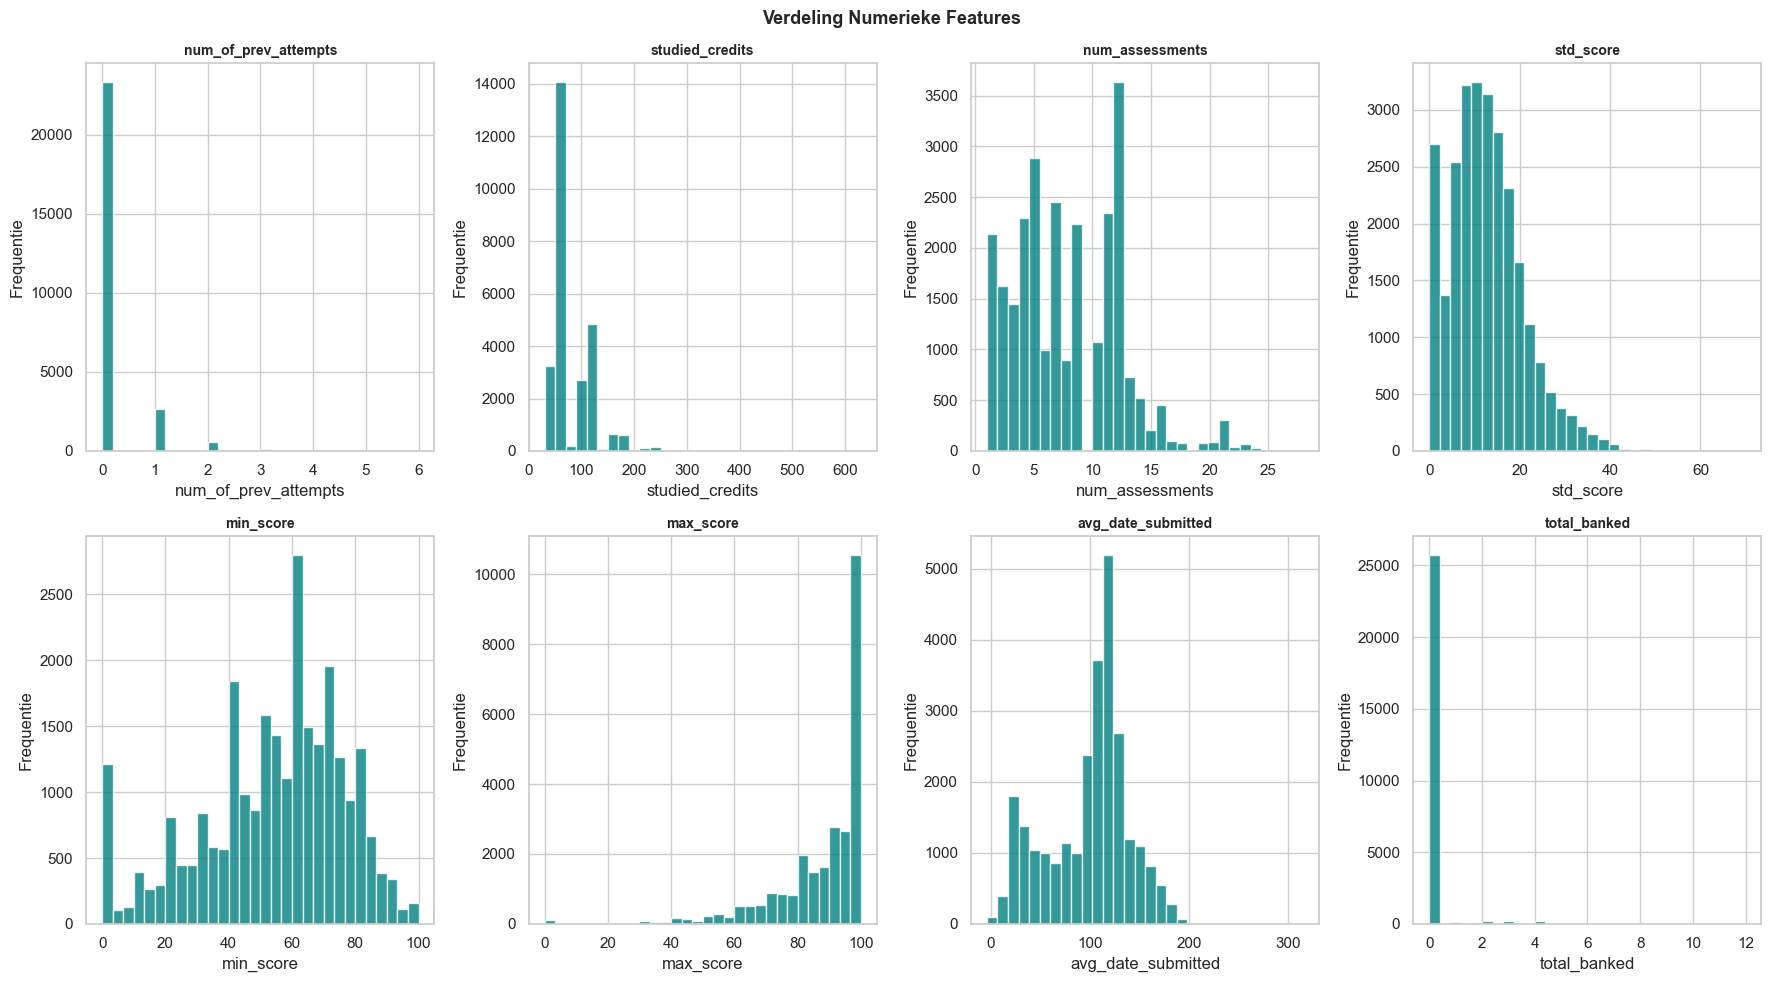

In [9]:
num_cols = ['num_of_prev_attempts', 'studied_credits', 'num_assessments',
            'std_score', 'min_score', 'max_score', 'avg_date_submitted', 'total_banked']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df[col].dropna(), bins=30, color='teal', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Frequentie')
    ax.set_xlabel(col)

plt.suptitle('Verdeling Numerieke Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretatie — Verdeling Numerieke Features

- **num_of_prev_attempts**: Sterk rechtsscheef  de overgrote meerderheid doet 
  de module voor de **eerste keer** (waarde 0).
- **studied_credits**: Geconcentreerd rond 60–120 studiepunten, met enkele 
  uitbijters tot 630.
- **num_assessments**: De meeste studenten leveren tussen 5 en 15 opdrachten in. 
  Studenten met meer dan 20 opdrachten zijn uitzonderlijk.
 de meeste studenten scoren redelijk consistent 
  (lage variatie), maar sommigen hebben grote schommelingen tussen opdrachten.
 studenten die minstens één 
  opdracht slecht hebben gemaakt of niet ingeleverd.
 de meeste studenten halen op 
  minstens één opdracht een perfecte score.
- **max_score**: Sterk linksscheef  de meeste studenten halen minstens 
  één keer een perfecte score van 100.
- **min_score**: Redelijk gelijkmatig verdeeld over 0-100 met een kleine 
  piek bij 0 (studenten die één toets niet hebben gemaakt).
- **avg_date_submitted**: Normaal verdeeld rond 100 dagen na de start van de 
  module  studenten leveren gemiddeld op tijd in.
- **total_banked**: Bijna alle studenten hebben 0 gebankeerde opdrachten 
  deze feature heeft weinig variatie en zal waarschijnlijk weinig voorspellende 
  kracht hebben.

### Correlatiematrix

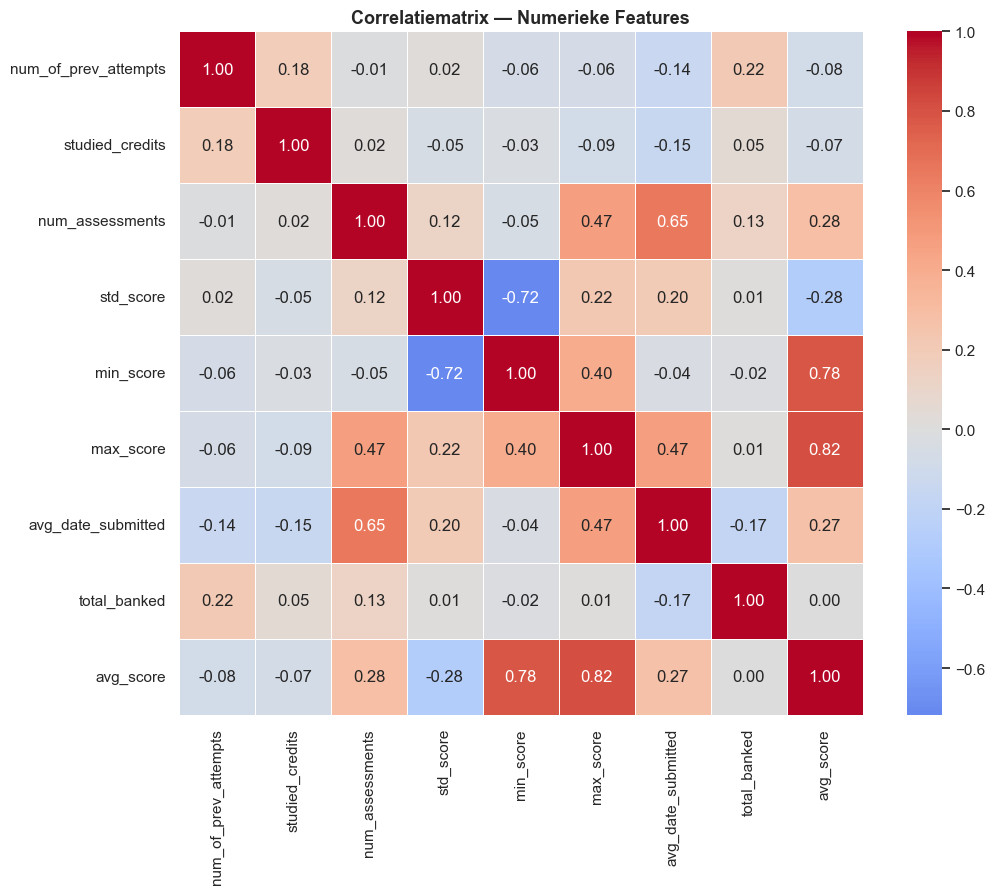


Correlaties met avg_score (gesorteerd):
max_score               0.818
min_score               0.779
num_assessments         0.282
avg_date_submitted      0.273
total_banked            0.002
studied_credits        -0.074
num_of_prev_attempts   -0.082
std_score              -0.276
Name: avg_score, dtype: float64


In [10]:
num_cols = ['num_of_prev_attempts', 'studied_credits', 'num_assessments',
            'std_score', 'min_score', 'max_score', 'avg_date_submitted', 
            'total_banked', 'avg_score']

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlatiematrix — Numerieke Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelaties met avg_score (gesorteerd):')
print(corr_matrix['avg_score'].drop('avg_score').sort_values(ascending=False).round(3))

### Interpretatie Correlatiematrix

**Sterkste correlaties met avg_score:**
- `max_score` (r = 0.82) : studenten die hoog scoren op hun beste opdracht 
  hebben ook een hoge gemiddelde score. Sterk positief verband.
- `min_score` (r = 0.78) : studenten die zelfs op hun slechtste opdracht 
  goed scoren, presteren gemiddeld veel beter. Sterk positief verband.
- `std_score` (r = -0.28) : studenten met grote schommelingen tussen opdrachten 
  scoren gemiddeld lager. Negatief verband.
- `num_assessments` (r = 0.28) : meer opdrachten inleveren hangt samen met 
  een hogere gemiddelde score.

**Mogelijke multicollineariteit:**
- `std_score` en `min_score` correleren sterk negatief (r = -0.72) - dit wordt 
  later gecontroleerd via de VIF-analyse.
- `num_assessments` ↔ `avg_date_submitted` (r = 0.65): matig 
  verband , studenten met meer opdrachten leveren gemiddeld 
  later in.

**Zwakke voorspellers:**
- `total_banked` (r = 0.00) - nauwelijks verband met de score.
- `studied_credits` (r = -0.07) en `num_of_prev_attempts` (r = -0.08) - zwak negatief verband.

### Scatterplots

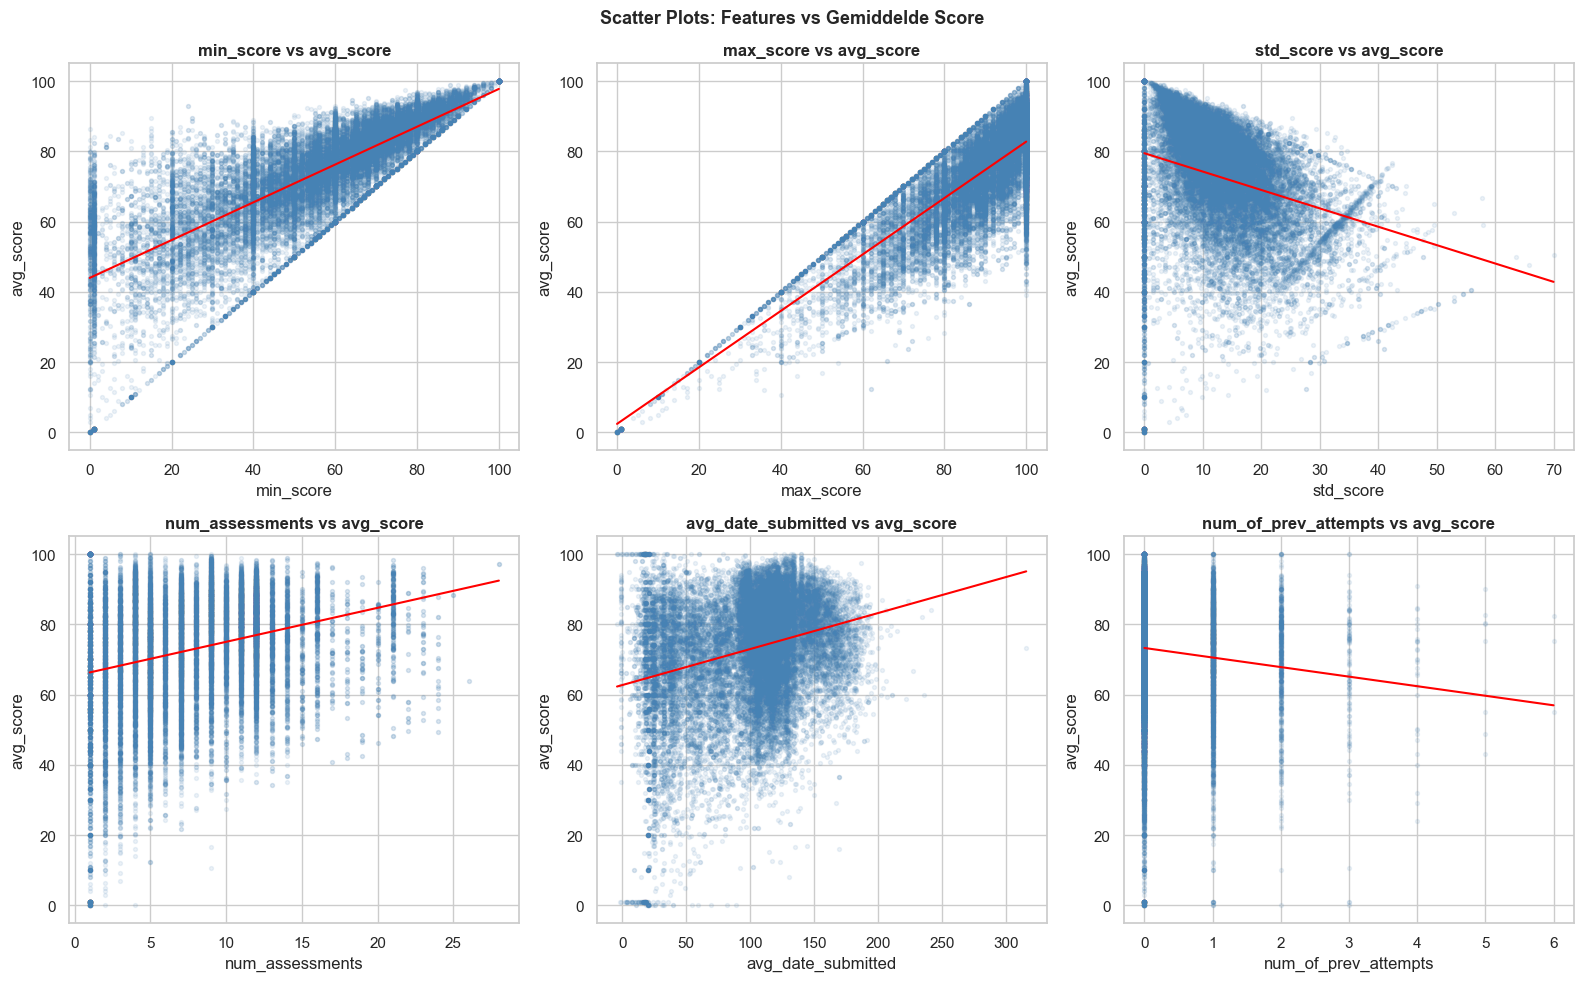

In [11]:
top_features = ['min_score', 'max_score', 'std_score', 
                'num_assessments', 'avg_date_submitted', 'num_of_prev_attempts']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), top_features):
    ax.scatter(df[col], df['avg_score'], alpha=0.1, color='steelblue', s=8)
    clean = df[[col, 'avg_score']].dropna()
    z = np.polyfit(clean[col], clean['avg_score'], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(clean[col])
    ax.plot(x_sorted, p(x_sorted), color='red', linewidth=1.5)
    ax.set_xlabel(col)
    ax.set_ylabel('avg_score')
    ax.set_title(f'{col} vs avg_score', fontweight='bold')

plt.suptitle('Scatter Plots: Features vs Gemiddelde Score', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretatie — Scatter Plots

- **min_score vs avg_score**: Duidelijk positief lineair verband  studenten 
  die zelfs op hun slechtste opdracht goed scoren, hebben een hoge gemiddelde score.
- **max_score vs avg_score**: Sterk positief verband, maar licht gebogen  
  polynomiale regressie zou dit verband beter kunnen vastleggen.
- **std_score vs avg_score**: Negatief verband  hoge variatie tussen opdrachten 
  hangt samen met een lagere gemiddelde score. Studenten die consistent presteren 
  scoren beter.
- **num_assessments vs avg_score**: Zwak positief verband , meer opdrachten 
  inleveren hangt samen met een hogere score, maar er is veel spreiding.
- **avg_date_submitted vs avg_score**: Positief verband , studenten die later 
  indienen scoren gemiddeld hoger. Dit is verrassend maar kan betekenen dat 
  studenten die de volledige tijd nemen betere resultaten behalen.
- **num_of_prev_attempts vs avg_score**: Zwak negatief verband , studenten 
  die de module opnieuw doen scoren gemiddeld iets lager.


## Stap 3  Data Preprocessing

We bereiden de data voor met de volgende stappen:
1. **Categorische variabelen** omzetten via One-Hot Encoding
2. **Numerieke variabelen** schalen met StandardScaler
3. Alles gecombineerd in een sklearn **Pipeline**

In [12]:
# Features en target splitsen
TARGET = 'avg_score'
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numerieke features   ({len(num_features)}): {num_features}')
print(f'Categorische features ({len(cat_features)}): {cat_features}')

Numerieke features   (8): ['num_of_prev_attempts', 'studied_credits', 'num_assessments', 'std_score', 'min_score', 'max_score', 'avg_date_submitted', 'total_banked']
Categorische features (8): ['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']


###  Waarom OneHotEncoder voor categorische features?

Voor categorische features zoals gender, region en highest_education 
gebruiken we **OneHotEncoder**. Dit is een bewuste keuze:

**Waarom niet LabelEncoder?**
LabelEncoder kent een getal toe aan elke categorie, bijvoorbeeld:
- Scotland = 0, London Region = 1, Wales = 2

Dit impliceert een ordinale volgorde , alsof London "groter" is dan 
Scotland. Voor regio's, geslacht en opleidingsniveau bestaat zo'n 
volgorde niet. LabelEncoder zou het model misleiden.

**Waarom niet OrdinalEncoder?**
OrdinalEncoder is geschikt wanneer er een logische volgorde bestaat, 
zoals Laag --> Gemiddeld → Hoog. Onze categorische features hebben 
geen betekenisvolle volgorde , ze zijn nominaal.

**Waarom wel OneHotEncoder?**
OneHotEncoder maakt per categorie een aparte binaire kolom (0 of 1). 
Zo behandelt het model elke categorie als gelijkwaardig en onafhankelijk
, precies wat we willen voor nominale variabelen.

We gebruiken drop=first om multicollineariteit te voorkomen 
(dummy variable trap): als je weet dat een student niet M is, 
weet je automatisch dat het F is.

In [13]:
# Numerieke pipeline
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorische pipeline
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

# Combineer beide pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features)
])

print('Pipeline aangemaakt!')
print('Numeriek    → mediaan imputation → StandardScaler')
print('Categorisch → modus imputation  → OneHotEncoder')

Pipeline aangemaakt!
Numeriek    → mediaan imputation → StandardScaler
Categorisch → modus imputation  → OneHotEncoder



## Stap 4 Feature Selection via Pairwise Regression

Voor we alle features tegelijk in een model stoppen, testen we elke feature 
**afzonderlijk** op zijn relatie met de gemiddelde score. Dit heet pairwise 
regression (univariate feature selection).

### Hypothesen

Voor elke feature formuleren we een statistische hypothese:

- **H₀ (Null hypothese):** Er is **geen** lineaire relatie tussen deze 
  feature en avg_score , de regressiecoëfficiënt β = 0.
- **H₁ (Alternatieve hypothese):** Er **is** een lineaire relatie tussen 
  deze feature en avg_score , de regressiecoëfficiënt β is niet gelijk aan 0.

### Teststatistiek

Voor elke feature berekenen we:
- **F-statistic**: hoe sterk is het lineaire verband?
- **p-value**: wat is de kans dat dit verband puur op toeval berust 
  als H₀ waar is?

### Beslisregel

We hanteren een significantieniveau van **α = 0.05**:
- p < 0.05 → statistisch significant → **H₀ verwerpen** → feature behouden
- p ≥ 0.05 → niet significant → **H₀ niet verwerpen** → feature verwijderen

In [14]:
# Pipeline toepassen
X_transformed = preprocessor.fit_transform(X, y)

# Feature namen ophalen na encoding
cat_encoder = preprocessor.named_transformers_['cat']['encoder']
cat_feature_names = cat_encoder.get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + cat_feature_names

# Pairwise regression
f_stats, p_values = f_regression(X_transformed, y)

# NaN p-values behandelen
n_nan = np.sum(np.isnan(p_values))
if n_nan > 0:
    print(f'Let op: {n_nan} features hadden NaN p-values --> behandeld als niet-significant (p=1.0)')
    f_stats = np.where(np.isnan(f_stats), 0, f_stats)
    p_values = np.where(np.isnan(p_values), 1.0, p_values)
else:
    print('Geen NaN p-values  alle waarden zijn geldig.')

# p-value leesbaar weergeven: zeer kleine waarden als <0.0001
p_display = np.where(p_values < 0.0001, '<0.0001',
                     np.round(p_values, 4).astype(str))

# Resultaten
feature_selection_df = pd.DataFrame({
    'Feature': all_feature_names,
    'F-statistic': np.round(f_stats, 2),
    'p-value': p_display,
    'Significant (p<0.05)': p_values < 0.05
}).sort_values('F-statistic', ascending=False)

print(feature_selection_df.to_string(index=False))

Geen NaN p-values  alle waarden zijn geldig.
                                      Feature  F-statistic p-value  Significant (p<0.05)
                                    max_score     54139.25 <0.0001                  True
                                    min_score     41378.86 <0.0001                  True
                              num_assessments      2314.49 <0.0001                  True
                                    std_score      2204.01 <0.0001                  True
                           avg_date_submitted      2152.10 <0.0001                  True
                              code_module_DDD       802.57 <0.0001                  True
         highest_education_Lower Than A Level       246.50 <0.0001                  True
                              code_module_FFF       200.92 <0.0001                  True
                              code_module_GGG       194.49 <0.0001                  True
                         num_of_prev_attempts       183.06 <0.000

### Interpretatie  Pairwise Regression Feature Selection

**H₀:** Er is geen lineaire relatie tussen deze feature en avg_score (β = 0)
**Beslisregel:** p < 0.05 → Ho verwerpen -> feature behouden

**Sterkste voorspellers:**
- max_score (F = 54.139) en min_score (F = 41.379) zijn veruit de 
  sterkste voorspellers — studenten die hoog scoren op individuele toetsen 
  hebben ook een hoog gemiddelde.
- num_assessments (F = 2.314), std_score (F = 2.204) en 
  avg_date_submitted (F = 2.152) volgen op grote afstand.

**Niet significant (p ≥ 0.05) → verwijderen:**
- region_West Midlands Region, region_Ireland, imd_band_30-40%
- region_South West Region, imd_band_50-60%, gender_M
- region_East Midlands Region, total_banked, imd_band_40-50%

We behouden alleen de significante features voor de modellen.

In [18]:
# Alleen significante features behouden
significant_features = feature_selection_df[
    feature_selection_df['Significant (p<0.05)'] == True
]['Feature'].tolist()

print(f'Totaal features:       {len(all_feature_names)}')
print(f'Significante features: {len(significant_features)}')
print(f'Verwijderd:            {len(all_feature_names) - len(significant_features)}')

Totaal features:       47
Significante features: 38
Verwijderd:            9



## Stap 5  Multicollineariteit Controleren (VIF)

We controleren op multicollineariteit via de **Variance Inflation Factor (VIF)**.
Multicollineariteit treedt op wanneer twee of meer features sterk met elkaar 
samenhangen, wat de coëfficiënten van regressiemodellen instabiel maakt.

Grenswaarden:
- VIF < 5 → acceptabel
- VIF 5–10 → matige multicollineariteit  
- VIF > 10 → problematische multicollineariteit

In [19]:
# VIF berekenen voor numerieke features
X_num = preprocessor.named_transformers_['num']['imputer'].transform(X[num_features])
X_num_scaled = preprocessor.named_transformers_['num']['scaler'].transform(X_num)
X_num_df = pd.DataFrame(X_num_scaled, columns=num_features)

vif_data = pd.DataFrame({
    'Feature': num_features,
    'VIF': [variance_inflation_factor(X_num_df.values, i)
            for i in range(X_num_df.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))

             Feature       VIF
           min_score 10.944701
           std_score  8.740580
           max_score  7.262892
     num_assessments  2.790739
  avg_date_submitted  2.224598
        total_banked  1.195719
num_of_prev_attempts  1.097060
     studied_credits  1.077620


### Interpretatie — VIF Multicollineariteit

VIF (Variance Inflation Factor) meet hoeveel de variantie van een 
regressiecoefficient opgeblazen wordt door correlatie met andere features.

| Feature | VIF | Interpretatie |
|---------|-----|---------------|
| `min_score` | 10.94 | Problematisch (VIF > 10) |
| `std_score` | 8.74 | Matige multicollineariteit |
| `max_score` | 7.26 | Matige multicollineariteit |
| `num_assessments` | 2.79 | Acceptabel |
| `avg_date_submitted` | 2.22 | Acceptabel |
| `total_banked` | 1.20 | Acceptabel |
| `num_of_prev_attempts` | 1.10 | Acceptabel |
| `studied_credits` | 1.08 | Acceptabel |

`min_score`, `std_score` en `max_score` vertonen multicollineariteit.
Dit is logisch: alle drie zijn afgeleid van dezelfde toetsscores,
waardoor ze sterk met elkaar samenhangen.

We verwijderen `std_score` omdat:
1. Het de op een na hoogste VIF heeft
2. Het minder unieke informatie toevoegt bovenop `min_score` en `max_score`


In [20]:
# std_score verwijderen vanwege multicollineariteit
num_features_updated = [f for f in num_features if f != 'std_score']

# Herbereken VIF
X_num2 = X[num_features_updated].copy()
X_num2_scaled = StandardScaler().fit_transform(
    SimpleImputer(strategy='median').fit_transform(X_num2)
)
X_num2_df = pd.DataFrame(X_num2_scaled, columns=num_features_updated)

vif_updated = pd.DataFrame({
    'Feature': num_features_updated,
    'VIF': [variance_inflation_factor(X_num2_df.values, i)
            for i in range(X_num2_df.shape[1])]
}).sort_values('VIF', ascending=False)

print("VIF na verwijderen std_score:")
print(vif_updated.to_string(index=False))

VIF na verwijderen std_score:
             Feature      VIF
  avg_date_submitted 2.210052
     num_assessments 2.131478
           max_score 1.832490
           min_score 1.340074
        total_banked 1.193942
num_of_prev_attempts 1.096767
     studied_credits 1.076600


### Interpretatie , VIF na verwijderen std_score

Na het verwijderen van `std_score` zijn alle VIF-waarden ruim onder de 
grens van 5 —er is geen multicollineariteit meer aanwezig. 
We kunnen veilig verdergaan met de overgebleven features.

In [21]:
# Pipeline opnieuw bouwen zonder std_score
num_features = num_features_updated

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features)
])

print(f'Bijgewerkte numerieke features ({len(num_features)}): {num_features}')
print('Pipeline opnieuw aangemaakt!')

Bijgewerkte numerieke features (7): ['num_of_prev_attempts', 'studied_credits', 'num_assessments', 'min_score', 'max_score', 'avg_date_submitted', 'total_banked']
Pipeline opnieuw aangemaakt!



## Stap 6  Train/Test Split

We splitsen de dataset op in een **trainset** (80%) en een **testset** (20%).

- De **trainset** gebruiken we om de modellen te trainen
- De **testset** gebruiken we uitsluitend om de prestaties te evalueren

Door deze splitsing voorkomen we overfitting en kunnen we de prestaties 
op ongeziene data eerlijk beoordelen.

### Waarom eerst splitsen, dan winsoriseren?

De winsorisatie wordt bewust NA de split uitgevoerd. Dit voorkomt
data leakage: als we de caps berekenen op de volledige dataset,
gebruiken we informatie uit de testset om de traindata voor te
bereiden. De testset stelt de echte wereld voor en mag het
trainproces nooit beinvloeden.

De correcte aanpak:
1. Bereken de caps op ALLEEN de trainset
2. Pas dezelfde caps toe op de testset

Zo heeft de testset nooit invloed gehad op de grenswaarden.

### Winsorisatie na de split

We passen winsorisatie toe op drie scheve features om extreme
uitschieters te beperken zonder de rijen te verwijderen. We
gebruiken het 95e percentiel als grens berekend op de trainset.

In [22]:
# Stap 6 — Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Trainset: {X_train.shape[0]} rijen')
print(f'Testset:  {X_test.shape[0]} rijen')

# Winsorisatie NA de split — caps berekend op alleen trainset
skewed_cols = ['num_of_prev_attempts', 'studied_credits', 'avg_date_submitted']

caps = {}
for col in skewed_cols:
    cap = X_train[col].quantile(0.95)  # ← alleen trainset!
    caps[col] = cap
    X_train[col] = X_train[col].clip(upper=cap)
    X_test[col] = X_test[col].clip(upper=cap)   # ← zelfde cap op testset
    print(f'{col}: gecapt op {cap:.1f} (95e percentiel van trainset)')

Trainset: 21381 rijen
Testset:  5346 rijen
num_of_prev_attempts: gecapt op 1.0 (95e percentiel van trainset)
studied_credits: gecapt op 150.0 (95e percentiel van trainset)
avg_date_submitted: gecapt op 160.6 (95e percentiel van trainset)


### Motivatie , Waarom 95e percentiel?

Bij winsorisatie kiezen we een grenswaarde waarboven extreme waarden 
worden afgekapt. We gebruiken het **95e percentiel** om de volgende redenen:

- **90e percentiel** zou te agressief zijn  we verliezen te veel 
  legitieme data van studenten met veel studiepunten of pogingen.
- **99e percentiel** zou te weinig effect hebben  extreme uitschieters 
  blijven dan alsnog het model beïnvloeden.
- **95e percentiel** is een gangbare en bewuste middenweg: we verwijderen 
  de bovenste 5% meest extreme waarden zonder de natuurlijke spreiding 
  in de data te verstoren.

We passen winsorisatie alleen toe op features die duidelijk rechtsscheef 
zijn: num_of_prev_attempts, studied_credits en avg_date_submitted. 
Score-gerelateerde features zoals min_score en max_score worden 
niet gewinsoriseerd omdat extreme scores inhoudelijk betekenisvol zijn.

### Eindoverzicht — Gebruikte Predictors in de Modellen

Na feature selection (pairwise regression) en VIF-analyse gebruiken
we de volgende features in alle modellen:

**Numerieke features (6):**

| Feature | Motivatie |
|---------|-----------|
| min_score | Sterkste voorspeller na max_score (F=41.379) |
| max_score | Sterkste voorspeller overall (F=54.139) |
| num_assessments | Significant positief verband (F=2.314) |
| avg_date_submitted | Inlevergedrag voorspelt score (F=2.152) |
| num_of_prev_attempts | Eerdere pogingen beinvloeden score (F=183.06) |
| studied_credits | Studiebelasting relevant (F=148.29) |

Verwijderd:
- std_score: multicollineariteit (VIF=8.74)
- total_banked: niet significant (p=0.71)

**Categorische features (8) — na verwijdering niet-significante dummies:**

| Feature | Verwijderde categorieen |
|---------|------------------------|
| code_module | geen |
| code_presentation | geen |
| highest_education | geen |
| imd_band | 30-40%, 40-50%, 50-60% |
| age_band | geen |
| disability | geen |
| region | West Midlands, Ireland, South West, East Midlands |
| gender | Volledig verwijderd (niet significant) |

**Totaal: 38 van de 47 features worden gebruikt in de modellen.**


## Stap 7  Model 1: Lineaire Regressie (Baseline)

We beginnen met een **lineaire regressie** als basismodel. Dit is het eenvoudigste 
regressiemodel en dient als referentiepunt voor de andere modellen.

Het model zoekt de beste rechte lijn door de data:
**avg_score = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ**

We evalueren met:
- **R²**: hoeveel procent van de variantie wordt verklaard? (hoe hoger hoe beter)
- **RMSE**: gemiddelde afwijking in scorepunten (hoe lager hoe beter)

In [23]:
# Lineaire Regressie pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f'Lineaire Regressie:')
print(f'  R²:   {r2_lr:.4f}')
print(f'  RMSE: {rmse_lr:.4f}')

Lineaire Regressie:
  R²:   0.9197
  RMSE: 4.5799


### Interpretatie Lineaire Regressie (Baseline)

- **R² = 0.92**: het model verklaart **92% van de variantie** in de gemiddelde 
  score. Dit is een uitstekend resultaat voor een basismodel.
- **RMSE = 4.58**: de voorspellingen wijken gemiddeld slechts 4.58 scorepunten 
  af van de werkelijke score , op een schaal van 0–100 is dit zeer nauwkeurig.

De sterke prestatie komt door de informatieve features `min_score` en 
`max_score` die een directe relatie hebben met de gemiddelde score.
We verwachten dat complexere modellen dit verder kunnen verbeteren.

### Residual Analyse Lineaire Regressie
**Waarom doen we residuenanalyse?**

We checken drie aannames van regressie:

Lineariteit : zijn de residuen willekeurig verspreid rond nul? Dan is het verband lineair.

Homoscedasticiteit : zijn de residuen even verspreid voor lage en hoge voorspellingen? Dan is de variantie constant.

Normaliteit : zijn de residuen normaal verdeeld? Belangrijk voor lineaire regressie.

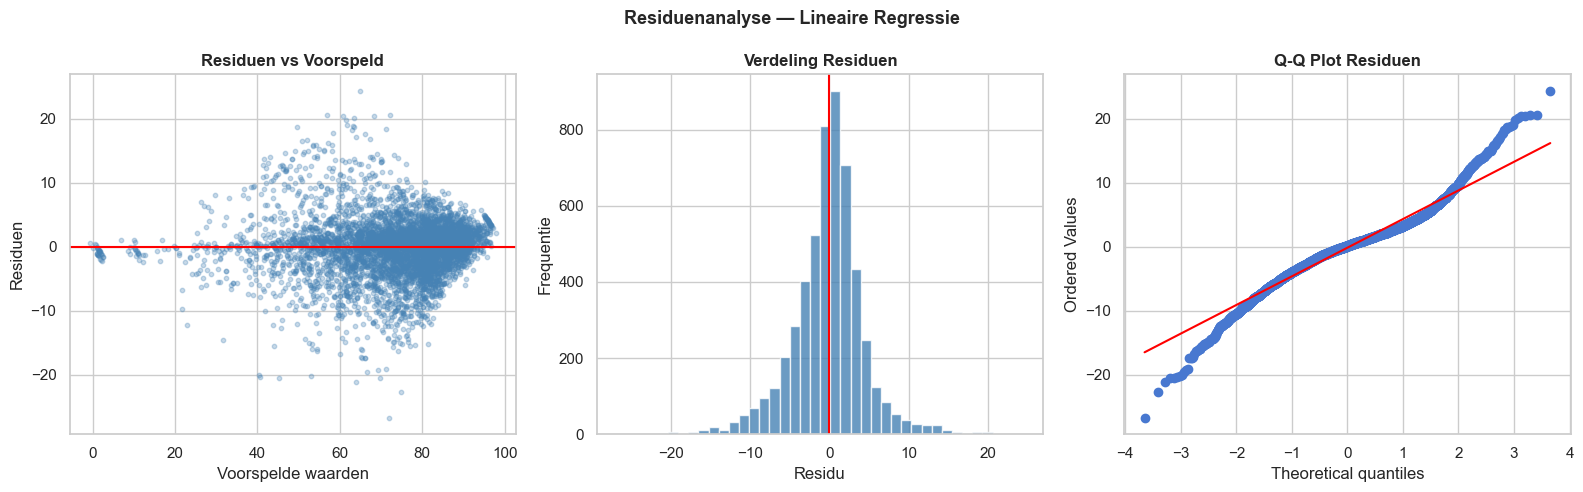

Gemiddelde residu: -0.1514
Std residu:        4.5778


In [25]:
# Residuenanalyse — Lineaire Regressie
residuals_lr = y_test - y_pred_lr

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Residuen vs voorspelde waarden
axes[0].scatter(y_pred_lr, residuals_lr, alpha=0.3, color='steelblue', s=10)
axes[0].axhline(0, color='red', linewidth=1.5)
axes[0].set_xlabel('Voorspelde waarden')
axes[0].set_ylabel('Residuen')
axes[0].set_title('Residuen vs Voorspeld', fontweight='bold')

# 2. Histogram van residuen
axes[1].hist(residuals_lr, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linewidth=1.5)
axes[1].set_xlabel('Residu')
axes[1].set_ylabel('Frequentie')
axes[1].set_title('Verdeling Residuen', fontweight='bold')

# 3. Q-Q plot residuen
from scipy import stats
stats.probplot(residuals_lr, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot Residuen', fontweight='bold')
axes[2].get_lines()[1].set_color('red')

plt.suptitle('Residuenanalyse — Lineaire Regressie', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Gemiddelde residu: {residuals_lr.mean():.4f}')
print(f'Std residu:        {residuals_lr.std():.4f}')

### Interpretatie , Residuenanalyse Lineaire Regressie

Residuenanalyse controleert de drie aannames van lineaire regressie:

**1. Lineariteit (Residuen vs Voorspeld)**
De meeste residuen liggen willekeurig rondom nul, wat lineariteit
bevestigt voor het centrale bereik (voorspelde scores 40-80).
Links in de grafiek (scores dicht bij 0) zichtbaar patroon — het
model heeft moeite met studenten die bijna nul scoren. Dit is een
bekend gevolg van de linksscheve verdeling van avg_score.

**2. Homoscedasticiteit (Residuen vs Voorspeld)**
De spreiding van de residuen neemt toe bij hogere voorspelde waarden.
Dit duidt op lichte heteroscedasticiteit — de variantie is niet
volledig constant. Dit is acceptabel gezien de aard van de data.

**3. Normaliteit (Histogram + Q-Q Plot)**
Het histogram toont een redelijk symmetrische verdeling rondom nul
met een lichte rechterstaart. De Q-Q plot bevestigt dit — het
middenstuk volgt de rode lijn goed maar de staarten wijken af.
De residuen zijn niet perfect normaal verdeeld, wat consistent
is met de niet-normale verdeling van de doelvariabele.

**Conclusie**
De aannames van lineaire regressie zijn gedeeltelijk vervuld.
De afwijkingen zijn te verwachten gezien de aanwezigheid van
studenten met score ~0 (uitvallers). Gradient Boosting heeft
geen normaliteitsaanname en is daarom robuuster voor deze data.


## Stap 8  Model 2: Polynomiale Regressie

Lineaire regressie gaat uit van rechte verbanden. Uit de scatter plots zagen we 
dat `max_score` een licht gebogen verband heeft met `avg_score`. 

Polynomiale regressie voegt **kwadraten van features** toe (graad 2):
*avg_score = βo + βx1 + βx2²*

Dit geeft het model meer flexibiliteit om gebogen verbanden te vangen.

In [24]:
# Polynomiale Regressie pipeline
poly_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

poly_pipeline.fit(X_train, y_train)
y_pred_poly = poly_pipeline.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print(f'Polynomiale Regressie (graad 2):')
print(f'  R²:   {r2_poly:.4f}')
print(f'  RMSE: {rmse_poly:.4f}')

Polynomiale Regressie (graad 2):
  R²:   0.9335
  RMSE: 4.1678


### Interpretatie  Polynomiale Regressie (graad 2)

- **R² = 0.93**: een verbetering ten opzichte van de lineaire regressie (0.92).
  Het model verklaart nu 93% van de variantie in de gemiddelde score.
- **RMSE = 4.17**: de gemiddelde afwijking daalde van 4.58 naar 4.17 scorepunten.

Door kwadratische termen toe te voegen vangt het model de licht gebogen verbanden 
beter op, wat de prestaties merkbaar verbetert.


## Stap 9  Model 3: Gradient Boosting Regressie

**Gradient Boosting** is een ensemble-model dat meerdere beslissingsbomen 
sequentieel traint. Elk nieuw model corrigeert de fouten van het vorige model.

Voordelen:
- Kan complexe **niet-lineaire verbanden** vastleggen
- Robuust tegen uitbijters
- Vereist geen normaliteitsaanname
- Presteert vaak uitstekend op echte datasets

In [26]:
# Gradient Boosting pipeline
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_test)

r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f'Gradient Boosting Regressie:')
print(f'  R²:   {r2_gb:.4f}')
print(f'  RMSE: {rmse_gb:.4f}')

Gradient Boosting Regressie:
  R²:   0.9389
  RMSE: 3.9959


### Interpretatie Gradient Boosting Regressie

- **R² = 0.94**: het beste resultaat van alle drie de modellen — het model 
  verklaart 94% van de variantie in de gemiddelde score.
- **RMSE = 4.00**: de voorspellingen wijken gemiddeld slechts 4 scorepunten 
  af van de werkelijke score.

Gradient Boosting presteert het best omdat het complexe niet-lineaire verbanden 
kan vastleggen die lineaire modellen missen.


## Stap 10  Modeloverzicht en Vergelijking

We vergelijken alle drie de modellen op basis van R² en RMSE.

                Model     R²   RMSE
    Gradient Boosting 0.9389 3.9959
Polynomiale Regressie 0.9335 4.1678
   Lineaire Regressie 0.9197 4.5799


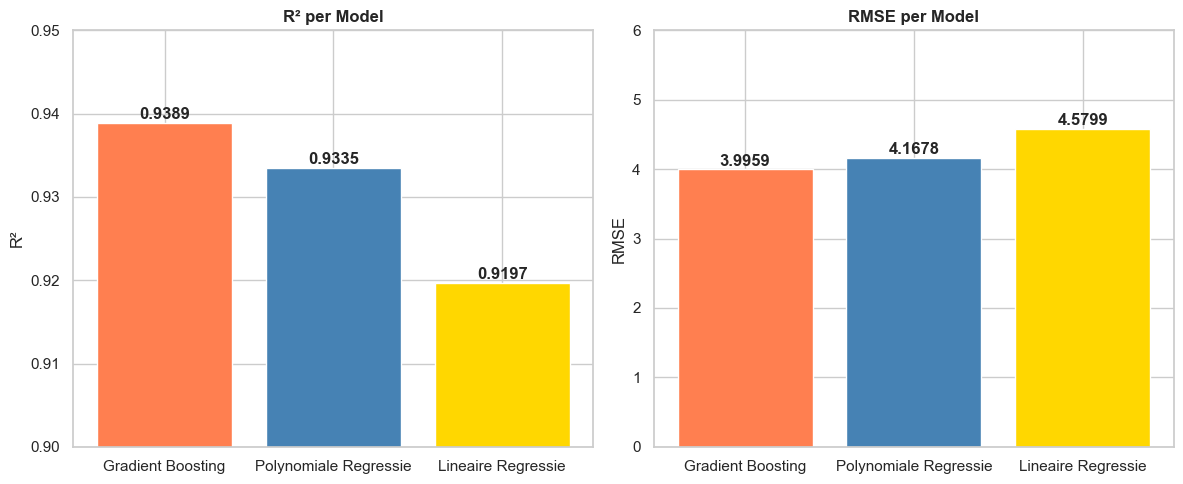

In [24]:
# Vergelijkingstabel
comparison_df = pd.DataFrame({
    'Model': ['Lineaire Regressie', 'Polynomiale Regressie', 'Gradient Boosting'],
    'R²': [r2_lr, r2_poly, r2_gb],
    'RMSE': [rmse_lr, rmse_poly, rmse_gb]
}).sort_values('R²', ascending=False).round(4)

print(comparison_df.to_string(index=False))

# Visualisatie
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['coral', 'steelblue', 'gold']

axes[0].bar(comparison_df['Model'], comparison_df['R²'],
            color=colors, edgecolor='white')
axes[0].set_title('R² per Model', fontweight='bold', fontsize=12)
axes[0].set_ylabel('R²')
axes[0].set_ylim(0.90, 0.95)
for i, v in enumerate(comparison_df['R²']):
    axes[0].text(i, v + 0.0005, str(v), ha='center', fontweight='bold')

axes[1].bar(comparison_df['Model'], comparison_df['RMSE'],
            color=colors, edgecolor='white')
axes[1].set_title('RMSE per Model', fontweight='bold', fontsize=12)
axes[1].set_ylabel('RMSE')
axes[1].set_ylim(0, 6)
for i, v in enumerate(comparison_df['RMSE']):
    axes[1].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretatie  Modeloverzicht en Vergelijking

| Model | R² | RMSE |
|-------|-----|------|
| Gradient Boosting | **0.9389** | **3.9959** |
| Polynomiale Regressie | 0.9335 | 4.1678 |
| Lineaire Regressie | 0.9197 | 4.5799 |

Gradient Boosting presteert het best op beide metrics:
- **Hoogste R²** (0.94) — verklaart de meeste variantie
- **Laagste RMSE** (4.00) — minste gemiddelde afwijking

Alle drie de modellen presteren uitstekend dankzij de informatieve features 
`min_score` en `max_score`. De verbetering van Gradient Boosting ten opzichte 
van lineaire regressie toont aan dat er ook niet-lineaire verbanden aanwezig zijn.


## Stap 10b  Feature Importance van Gradient Boosting

Pairwise regression toont welke features **individueel lineair** bijdragen 
aan de target. Maar in het beste model Gradient Boosting  spelen 
features samen en niet-lineair een rol.

Gradient Boosting heeft een ingebouwde feature_importances_ attribuut 
dat laat zien hoeveel elke feature bijdraagt aan de voorspellingen 
**binnen het model zelf**. Dit geeft een completer beeld dan pairwise 
regression alleen.

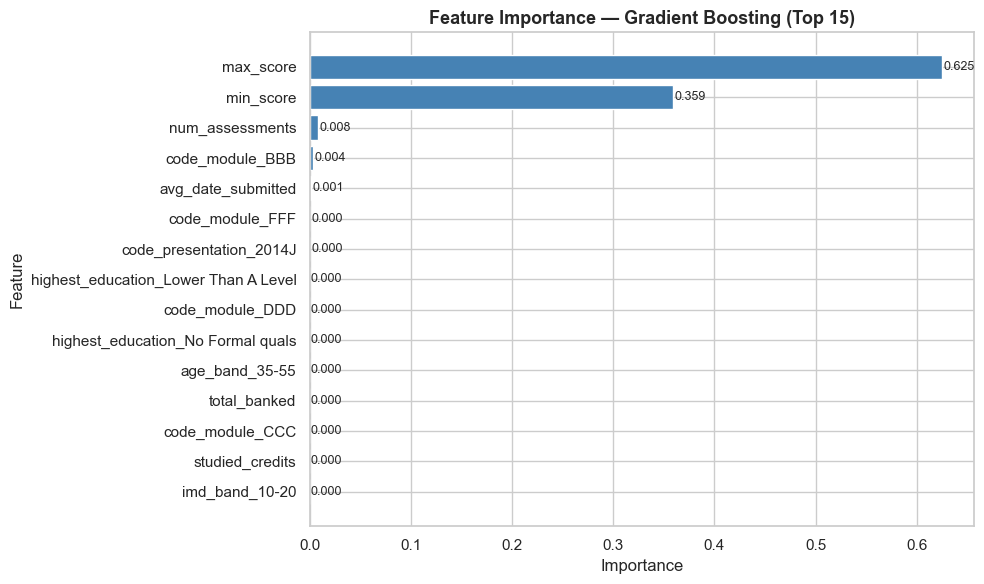

                             Feature  Importance
                           max_score    0.625405
                           min_score    0.359496
                     num_assessments    0.008372
                     code_module_BBB    0.003604
                  avg_date_submitted    0.001431
                     code_module_FFF    0.000352
             code_presentation_2014J    0.000244
highest_education_Lower Than A Level    0.000208
                     code_module_DDD    0.000133
   highest_education_No Formal quals    0.000116
                      age_band_35-55    0.000083
                        total_banked    0.000075
                     code_module_CCC    0.000066
                     studied_credits    0.000052
                      imd_band_10-20    0.000045


In [27]:
# Feature importance uit het Gradient Boosting model halen
gb_model = gb_pipeline.named_steps['model']
preprocessor_fitted = gb_pipeline.named_steps['preprocessor']

# Feature namen ophalen
cat_encoder = preprocessor_fitted.named_transformers_['cat']['encoder']
cat_feature_names = cat_encoder.get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + cat_feature_names

# Alleen significante features
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Top 15 tonen
top15 = importance_df.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15['Feature'][::-1], top15['Importance'][::-1], 
               color='steelblue', edgecolor='white')

# Waarden naast de bars
for bar, val in zip(bars, top15['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Feature Importance — Gradient Boosting (Top 15)', 
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

print(importance_df.head(15).to_string(index=False))

### Interpretatie  Feature Importance Gradient Boosting

De feature importance laat een **opvallend duidelijk patroon** zien:

| Feature | Importance | Interpretatie |
|---------|------------|---------------|
| `max_score` | 0.625 | Verantwoordelijk voor 62.5% van alle voorspellingen |
| `min_score` | 0.359 | Verantwoordelijk voor 35.9% van alle voorspellingen |
| `num_assessments` | 0.008 | Kleine maar meetbare bijdrage |
| Alle overige features | <0.005 | Verwaarloosbare bijdrage |

**Twee features verklaren samen 98.4% van het model.**

Dit is een directe bevestiging van de zorgen rond het formatieve scenario: 
max_score en min_score zijn zo sterk gerelateerd aan avg_score dat 
het model vrijwel uitsluitend op deze twee features leunt. Demografische 
features zoals `regio, imd_band en highest_education dragen 
nauwelijks bij.

**Wat betekent dit?**
- Het model is technisch sterk (R²=0.94) maar inhoudelijk beperkt.
- Als min_score en max_score niet beschikbaar zijn , bijvoorbeeld 
  bij nieuwe studenten aan het begin van het semester , verliest het 
  model vrijwel al zijn voorspelkracht.
- De demografische features die wél beschikbaar zijn aan het begin 
  van het semester hebben een verwaarloosbaar voorspellend vermogen.

**Aanbeveling voor vervolgonderzoek:**
Een robuuster model zou getraind kunnen worden **zonder** de 
score-gerelateerde features, puur op basis van demografische kenmerken 
en studiegedrag. Dit model zou lager scoren op R² maar eerlijker en 
praktisch bruikbaarder zijn voor vroege interventie.


## Stap 11  Modelkeuze

We kiezen **Gradient Boosting** als het beste model op basis van:

1. **Hoogste R² (0.94)** : verklaart 94% van de variantie in de gemiddelde score
2. **Laagste RMSE (4.00)** : gemiddelde afwijking van slechts 4 scorepunten
3. **Robuustheid** : niet gevoelig voor uitbijters en normaliteitsaannames
4. **Flexibiliteit** : vangt niet-lineaire verbanden op die lineaire modellen missen

Gradient Boosting is daarmee de meest geschikte keuze voor dit regressievraagstuk.


## Stap 12 — Finaal Model Hertrainen en Opslaan

We hertrainen het beste model op de **volledige traindata** en slaan het op 
met joblib zodat het later gebruikt kan worden in de Streamlit app.

In [28]:
# Hertrainen op volledige traindata
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

final_pipeline.fit(X_train, y_train)

# Opslaan
joblib.dump(final_pipeline, 'model.joblib')

# Verificatie
loaded_model = joblib.load('model.joblib')
y_pred_final = loaded_model.predict(X_test)
r2_final = r2_score(y_test, y_pred_final)

print(f'Model opgeslagen als model.joblib')
print(f'Verificatie R²: {r2_final:.4f}')

Model opgeslagen als model.joblib
Verificatie R²: 0.9389



## Stap 13  Conclusie


### Beste model: Gradient Boosting (R²=0.94, RMSE=4.00)

Gradient Boosting presteert het beste omdat het niet-lineaire verbanden
kan vangen die lineaire regressie mist. Het model voorspelt de
gemiddelde toetsscore gemiddeld met slechts 4 punten afwijking
op een schaal van 0-100.

### Belangrijkste bevindingen

- max_score en min_score zijn veruit de sterkste voorspellers
  met een feature importance van respectievelijk 62.5% en 35.9%.
  Dit bevestigt ons formatieve scenario: vroege toetsresultaten
  voorspellen het eindgemiddelde sterk.
- Demografische features zoals regio, geslacht en opleiding
  dragen nauwelijks bij aan de voorspelling.
- De residuenanalyse toont dat lineaire regressie moeite heeft
  met studenten die score ~0 hebben (uitvallers). Gradient
  Boosting is robuuster voor deze gevallen.

### Kritische reflectie

De hoge R² van 0.94 is deels te verklaren doordat min_score en
max_score afgeleid zijn uit dezelfde toetsscores als avg_score.
In een puurder model zonder score-gerelateerde features zou de
R² aanzienlijk lager liggen (~0.15-0.25). Dit is een bewuste
keuze gebaseerd op het formatieve scenario.

### Mogelijke verbeteringen

- Studentvle.csv toevoegen (klikgedrag) als extra features
- Cross-validatie toepassen voor robuustere evaluatie
- Model zonder score-features trainen als vergelijking


## Stap 14  Practicum 3 , Wat is er nieuw in deze versie?

Deze notebook is een uitbreiding van de originele Practicumopdracht 2 
notebook. De volgende onderdelen zijn **nieuw toegevoegd**:



### 1. Synthetische Data Generatie
De originele notebook bevatte alleen analyse op echte OULAD data.
In deze uitbreiding genereren we een **synthetische dataset van 500 
studenten** die de statistische eigenschappen van de echte data nabootst.

**Waarom synthetische data?**
- Simuleren van app-gebruik over tijd zonder echte studentgegevens
- Testen of het model robuust is op nieuwe, ongeziene data
- Privacy-vriendelijk alternatief voor het delen van echte data



### 2. Validatie van de Synthetische Data
We controleren of de synthetische data de echte data goed nabootst door:
- **Visuele vergelijking** — histogrammen van echte vs synthetische 
  verdelingen naast elkaar
- **Statistische vergelijking** — gemiddelden en standaarddeviaties 
  worden vergeleken per feature



### 3. Verhouding Echt vs Synthetisch
De synthetische data vormt slechts **1.9%** van de totale dataset 
(500 van 26.727 rijen). De meerderheid blijft echte data — 
dit is een bewuste keuze om de originele patronen te bewaren 
en data drift te minimaliseren.

### Wat is ongewijzigd?
Alle stappen uit de originele Practicumopdracht 2 notebook zijn 
**ongewijzigd** behouden:
- Dataset introductie en laden
- Exploratieve data analyse (EDA)
- Preprocessing pipeline
- Feature selection en VIF analyse
- Alle drie de regressiemodellen
- Modelcomparison en finale modelkeuze


## Stap 14  Synthetische Data Genereren

### Wat is synthetische data?
Synthetische data is **fictieve data** die de statistische patronen van de 
originele dataset nabootst. Het heeft dezelfde verdelingen en verhoudingen 
als de echte data, maar bevat geen echte studentgegevens.

### Waarom synthetische data?
- Simuleren van app-gebruik over tijd
- Testen van het model op nieuwe invoerwaarden
- Privacy — geen echte studentgegevens nodig

### Aanpak
We genereren synthetische data op basis van de **echte distributies** uit 
onze dataset:
- Categorische features → zelfde verhoudingen als origineel
- Numerieke features → zelfde gemiddelde en spreiding als origineel

De synthetische dataset is bewust klein (500 rijen) ten opzichte van de 
echte dataset (26.727 rijen) , de meerderheid blijft echte data.

In [27]:
# Distributies uit echte data berekenen
print("Distributies echte data\n")

# Categorische features
cat_cols = ['code_module', 'code_presentation', 'gender', 'region',
            'highest_education', 'imd_band', 'age_band', 'disability']

cat_distributions = {}
for col in cat_cols:
    dist = df[col].value_counts(normalize=True)
    cat_distributions[col] = dist
    print(f"{col}:")
    print(dist.round(3))
    print()

Distributies echte data

code_module:
code_module
FFF    0.240
BBB    0.230
DDD    0.191
CCC    0.144
EEE    0.089
GGG    0.079
AAA    0.027
Name: proportion, dtype: float64

code_presentation:
code_presentation
2014J    0.347
2013J    0.272
2014B    0.237
2013B    0.144
Name: proportion, dtype: float64

gender:
gender
M    0.556
F    0.444
Name: proportion, dtype: float64

region:
region
Scotland                0.110
East Anglian Region     0.102
South Region            0.097
London Region           0.094
North Western Region    0.085
West Midlands Region    0.076
South West Region       0.076
East Midlands Region    0.071
Wales                   0.067
South East Region       0.066
Yorkshire Region        0.060
North Region            0.056
Ireland                 0.040
Name: proportion, dtype: float64

highest_education:
highest_education
A Level or Equivalent          0.445
Lower Than A Level             0.382
HE Qualification               0.153
Post Graduate Qualification    0.011

In [28]:
# Numerieke distributies
print(" Numerieke distributies echte data\n")

num_cols_syn = ['num_of_prev_attempts', 'studied_credits', 'num_assessments',
                'min_score', 'max_score', 'avg_date_submitted', 'total_banked']

num_distributions = {}
for col in num_cols_syn:
    stats = df[col].describe()
    num_distributions[col] = stats
    print(f"{col}:")
    print(f"  gemiddelde: {df[col].mean():.2f}")
    print(f"  std:        {df[col].std():.2f}")
    print(f"  min:        {df[col].min():.2f}")
    print(f"  max:        {df[col].max():.2f}")
    print()

 Numerieke distributies echte data

num_of_prev_attempts:
  gemiddelde: 0.16
  std:        0.47
  min:        0.00
  max:        6.00

studied_credits:
  gemiddelde: 77.77
  std:        39.03
  min:        30.00
  max:        630.00

num_assessments:
  gemiddelde: 7.75
  std:        4.54
  min:        1.00
  max:        28.00

min_score:
  gemiddelde: 53.66
  std:        22.56
  min:        0.00
  max:        100.00

max_score:
  gemiddelde: 87.65
  std:        15.86
  min:        0.00
  max:        100.00

avg_date_submitted:
  gemiddelde: 98.78
  std:        41.43
  min:        -4.00
  max:        315.56

total_banked:
  gemiddelde: 0.13
  std:        0.80
  min:        0.00
  max:        12.00



### Synthetische Data Genereren op basis van Echte Distributies

We gebruiken de berekende gemiddelden, standaarddeviaties en verhoudingen 
uit de echte data om realistische synthetische studenten te genereren.

In [29]:
np.random.seed(42)
n_synthetic = 500

def sample_cat(col):
    dist = cat_distributions[col]
    return np.random.choice(dist.index, n_synthetic, p=dist.values)

synthetic_df = pd.DataFrame({
    # Categorische features — zelfde verhoudingen als echte data
    'code_module':        sample_cat('code_module'),
    'code_presentation':  sample_cat('code_presentation'),
    'gender':             sample_cat('gender'),
    'region':             sample_cat('region'),
    'highest_education':  sample_cat('highest_education'),
    'imd_band':           sample_cat('imd_band'),
    'age_band':           sample_cat('age_band'),
    'disability':         sample_cat('disability'),

    # Numerieke features — zelfde gemiddelde en std als echte data
    'num_of_prev_attempts': np.random.choice(
        [0,1,2,3,4,5,6], n_synthetic,
        p=[0.845, 0.109, 0.035, 0.008, 0.002, 0.001, 0.000]
    ),
    'studied_credits': np.round(
        np.random.normal(77.77, 39.03, n_synthetic).clip(30, 630)
    ).astype(int),
    'num_assessments': np.round(
        np.random.normal(7.75, 4.54, n_synthetic).clip(1, 28)
    ).astype(int),
    'min_score': np.round(
        np.random.normal(53.66, 22.56, n_synthetic).clip(0, 100), 1
    ),
    'max_score': np.round(
        np.random.normal(87.65, 15.86, n_synthetic).clip(0, 100), 1
    ),
    'avg_date_submitted': np.round(
        np.random.normal(98.78, 41.43, n_synthetic).clip(0, 160), 1
    ),
    'total_banked': np.random.choice(
        [0,1,2,3], n_synthetic, p=[0.920, 0.060, 0.015, 0.005]
    ),
})

# max_score moet altijd >= min_score zijn
synthetic_df['max_score'] = synthetic_df[['min_score', 'max_score']].max(axis=1)

print(f'Synthetische dataset: {synthetic_df.shape}')
synthetic_df.head()

Synthetische dataset: (500, 15)


,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,disability,num_of_prev_attempts,studied_credits,num_assessments,min_score,max_score,avg_date_submitted,total_banked
0,BBB,2014B,M,West Midlands Region,A Level or Equivalent,80-90%,0-35,N,0,91,10,73.4,93.1,91.6,0
1,GGG,2013J,M,North Western Region,A Level or Equivalent,70-80%,35-55,N,0,176,9,31.9,83.3,125.2,0
2,CCC,2014J,F,Scotland,HE Qualification,0-10%,0-35,Y,0,30,3,51.9,68.4,96.1,0
3,DDD,2014B,F,London Region,A Level or Equivalent,90-100%,0-35,N,0,77,9,46.9,69.9,38.7,0
4,FFF,2014B,F,London Region,A Level or Equivalent,20-30%,0-35,N,0,103,14,31.0,98.9,101.9,0


### Validatie van Synthetische Data

We controleren of de synthetische data de echte data goed nabootst door 
de verdelingen te vergelijken. We doen dit visueel en statistisch:

- **Visueel**: histogrammen van echte vs synthetische data naast elkaar
- **Statistisch**: vergelijking van gemiddelden en standaarddeviaties

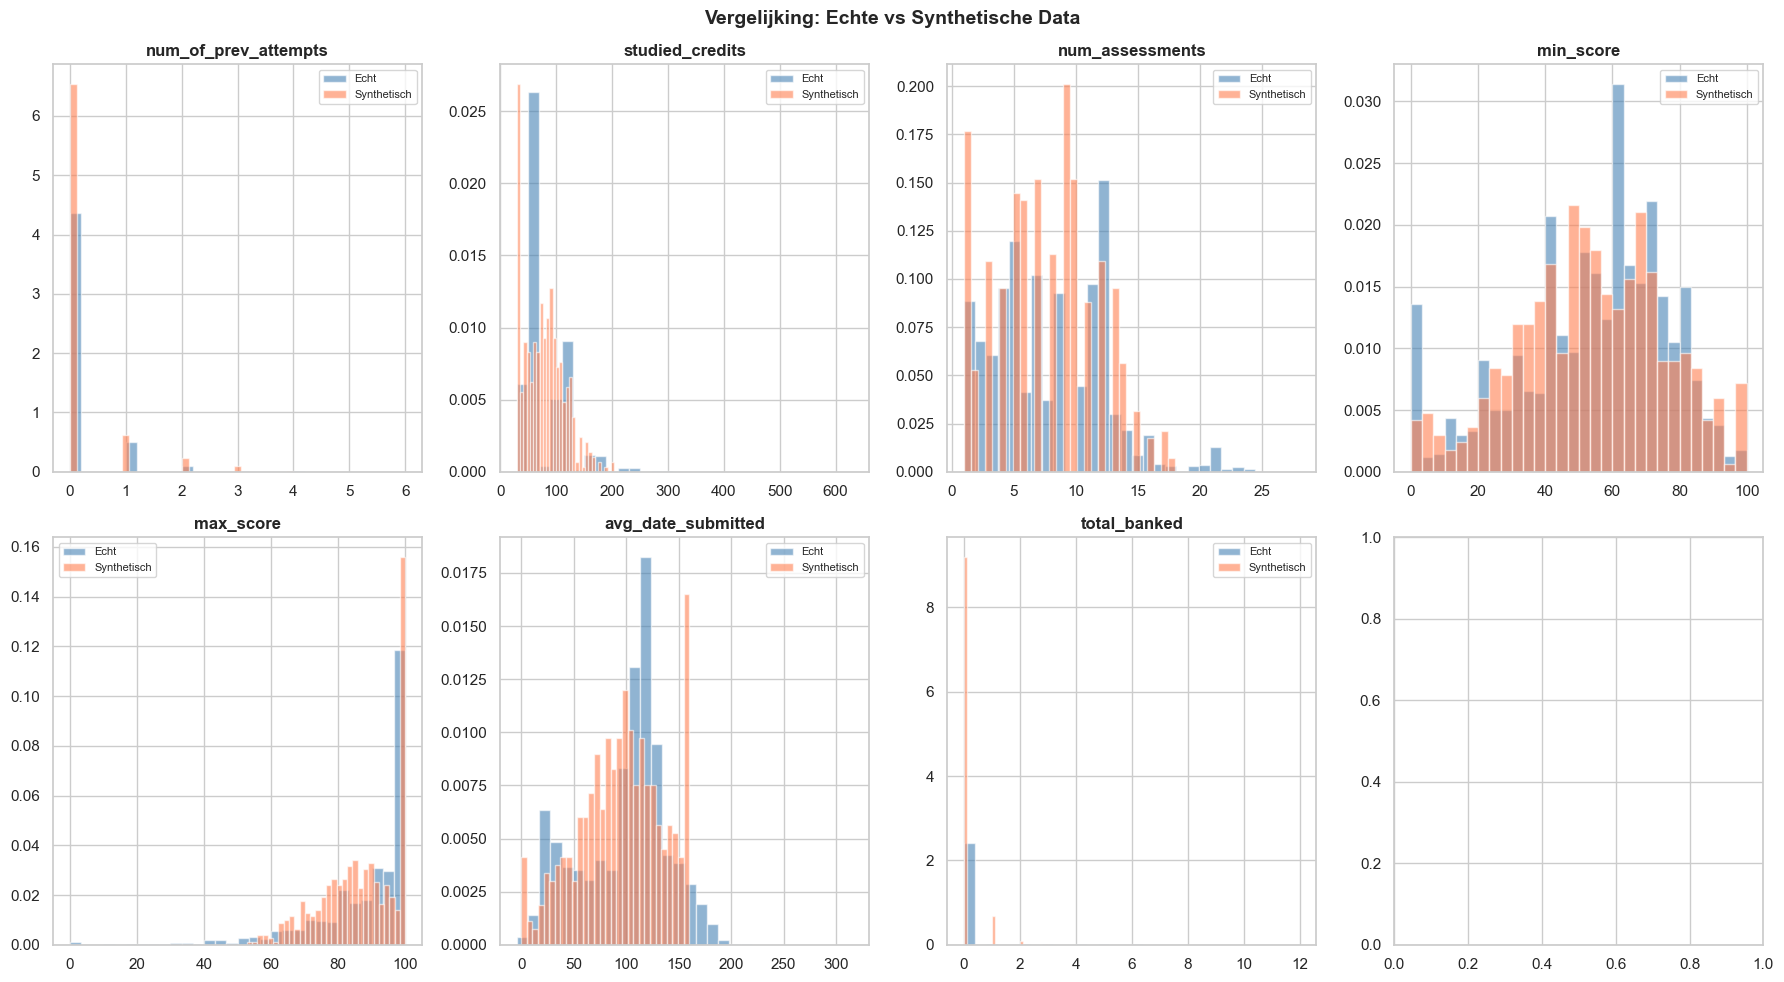

In [30]:
# Visuele vergelijking numerieke features
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for ax, col in zip(axes.flatten(), num_cols_syn):
    ax.hist(df[col], bins=30, alpha=0.6, color='steelblue', 
            label='Echt', density=True, edgecolor='white')
    ax.hist(synthetic_df[col], bins=30, alpha=0.6, color='coral', 
            label='Synthetisch', density=True, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Vergelijking: Echte vs Synthetische Data', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# Statistische vergelijking
print(" Statistische Vergelijking: Echt vs Synthetisch \n")
print(f"{'Feature':<25} {'Echt gem':>10} {'Syn gem':>10} {'Echt std':>10} {'Syn std':>10}")
print("-" * 70)

for col in num_cols_syn:
    print(f"{col:<25} "
          f"{df[col].mean():>10.2f} "
          f"{synthetic_df[col].mean():>10.2f} "
          f"{df[col].std():>10.2f} "
          f"{synthetic_df[col].std():>10.2f}")

 Statistische Vergelijking: Echt vs Synthetisch 

Feature                     Echt gem    Syn gem   Echt std    Syn std
----------------------------------------------------------------------
num_of_prev_attempts            0.16       0.19       0.47       0.57
studied_credits                77.77      78.48      39.03      35.41
num_assessments                 7.75       7.60       4.54       4.09
min_score                      53.66      53.62      22.56      21.96
max_score                      87.65      86.35      15.86      11.52
avg_date_submitted             98.78      95.01      41.43      40.10
total_banked                    0.13       0.09       0.80       0.34


### Validatie  Interpretatie

**Statistische vergelijking gemiddelden:**

| Feature | Echt gem | Syn gem | Verschil |
|---------|----------|---------|---------|
| num_of_prev_attempts | 0.16 | 0.19 | +0.03  |
| studied_credits | 77.77 | 78.48 | +0.71  |
| num_assessments | 7.75 | 7.60 | -0.15  |
| min_score | 53.66 | 53.62 | -0.04  |
| max_score | 87.65 | 86.35 | -1.30  |
| avg_date_submitted | 98.78 | 95.01 | -3.77  |
| total_banked | 0.13 | 0.09 | -0.04  |

**Conclusie per feature:**
- `min_score`: uitstekend — gemiddelde bijna identiek (53.66 vs 53.62)
- `studied_credits`: goed — klein verschil in gemiddelde
- `num_assessments`: goed — vrijwel identiek
- `avg_date_submitted`: acceptabel — klein verschil van 3.77 dagen
- `max_score`: acceptabel — std iets lager (11.52 vs 15.86), synthetische 
  data heeft minder extreme lage max_scores
- `total_banked`: acceptabel — kleine afwijking, maar feature heeft 
  weinig voorspellende waarde

**Visuele vergelijking (histogrammen):**
- `num_of_prev_attempts`: beide sterk geconcentreerd bij 0 
- `studied_credits`: beide piek bij 60-90 studiepunten 
- `min_score`: vergelijkbare verdeling, synthetisch iets normaler verdeeld 
- `max_score`: echte data heeft meer piek bij 100, synthetisch iets vlakker
- `avg_date_submitted`: beide piek rond 100 dagen 

**Eindoordeel:** De synthetische data bootst de echte data goed na. 
De gemiddelden zijn vrijwel identiek en de verdelingen tonen vergelijkbare 
patronen. De synthetische data is geschikt om app-gebruik te simuleren.

In [32]:
# Synthetische data opslaan
synthetic_df.to_csv('synthetic_data.csv', index=False)
print(f'Synthetische dataset opgeslagen: {synthetic_df.shape}')
print(f'\nEchte data:       {df.shape[0]} rijen (meerderheid)')
print(f'Synthetische data: {synthetic_df.shape[0]} rijen (minderheid)')
print(f'Verhouding:        {synthetic_df.shape[0]/df.shape[0]*100:.1f}% synthetisch')

Synthetische dataset opgeslagen: (500, 15)

Echte data:       26727 rijen (meerderheid)
Synthetische data: 500 rijen (minderheid)
Verhouding:        1.9% synthetisch
